In [3]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784',version=1,as_frame=False)
X,y = mnist.data, mnist.target
X[2]

X.shape



(70000, 784)

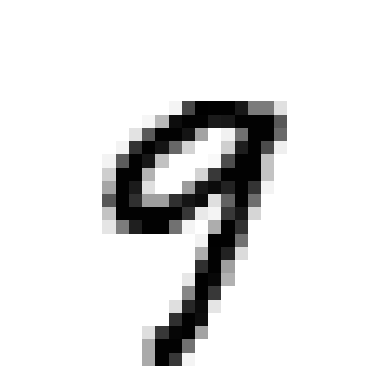

In [4]:
import matplotlib.pyplot as plt
def plot_digit(image_data):
    image = image_data.reshape(28,28)
    plt.imshow(image, cmap="binary")
    plt.axis('off')
some_digit = X[45]
plot_digit(some_digit)
plt.show()




In [5]:
y[0]

'5'

In [6]:
X_train, X_test, y_train, y_test = X[:60000],X[60000:],y[:60000],y[60000:]
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')
X_train.shape
X_test.shape
y_train_5.shape
y_test_5.shape
print(y_train_5.shape, X_train.shape)



(60000,) (60000, 784)


In [7]:
from sklearn.linear_model import SGDClassifier

sdg_clf = SGDClassifier(random_state=42)
sdg_clf.fit(X_train,y_train_5)
sdg_clf.predict([some_digit])





array([False])

In [8]:
from sklearn.model_selection import cross_val_score
cross_val_score(sdg_clf,X_train,y_train_5,cv=3,scoring="accuracy")






array([0.95035, 0.96035, 0.9604 ])

In [9]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sdg_clf,X_train,y_train_5, cv=3)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5,y_train_pred)
print(cm)


[[53892   687]
 [ 1891  3530]]


In [10]:
y_train_perfect_predictions = y_train_5
cm2 = confusion_matrix(y_train_5,y_train_perfect_predictions)
print(cm2)


[[54579     0]
 [    0  5421]]


In [11]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_5,y_train_pred)

0.8370879772350012

In [12]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

In [13]:
from sklearn.metrics import f1_score
f1_score(y_train_5,y_train_pred)

0.7325171197343847

In [14]:
y_scores = sdg_clf.decision_function([some_digit])
y_scores

array([-5893.27624997])

In [15]:
threshold = 0


In [16]:
y_some_digit_pred= 0

In [17]:
threshold=3000
y_some_digit_pred = (y_scores > threshold)
print(y_some_digit_pred)


[False]


In [18]:
from sklearn.metrics import precision_recall_curve
y_scores = cross_val_predict(sdg_clf,X_train, y_train_5, cv= 3, method= "decision_function")
precisions, recalls, thresholds = precision_recall_curve(y_train_5,y_scores)

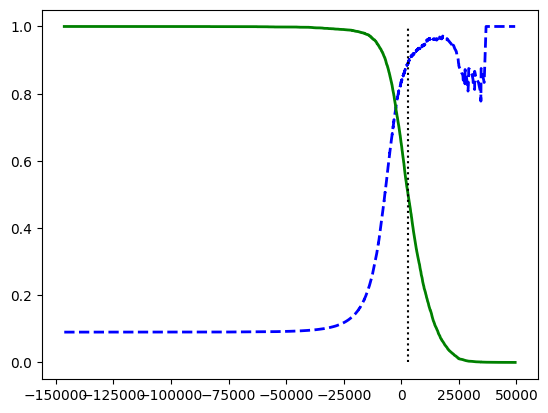

In [19]:
plt.plot(thresholds, precisions[:-1], "b--", label= "Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label= "Recall", linewidth=2)
plt.vlines(threshold, 0,1.0, "k", "dotted", label= "threshold")
[...]
plt.show()

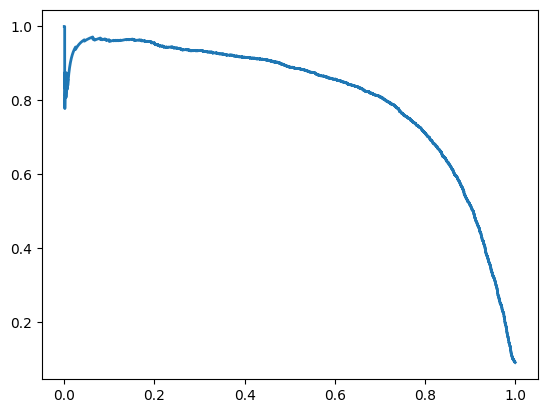

In [20]:
plt.plot(recalls,precisions,linewidth=2,label="precision/recall curve")
[...]
plt.show()


In [21]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
print(threshold_for_90_precision)


3370.0194991439557


In [22]:
y_train_pred_90= (y_scores >= threshold_for_90_precision )
precision_score = (y_train_5, y_train_pred_90)

recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)

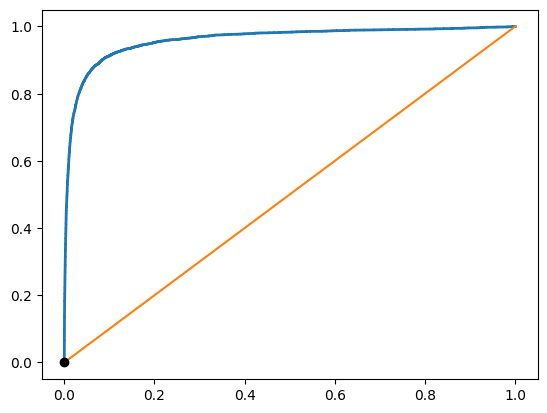

In [23]:
from sklearn.metrics import roc_curve
fpr, tpr, threshold = roc_curve(y_train_5, y_scores)
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90 , fpr_90, = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.plot(fpr,tpr,linewidth=2, label = "roc curve")
plt.plot([0,1], [0,1], label = "random classifier roc curve")
plt.plot([fpr_90],[tpr_90], "ko", label = "threshold for 90% precision")
[...]
plt.show()

In [24]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)


0.9604938554008616

In [25]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)

y_probas_forest = cross_val_predict(forest_clf, X_train,y_train_5, cv=3, method= "predict_proba")
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.99, 0.01]])

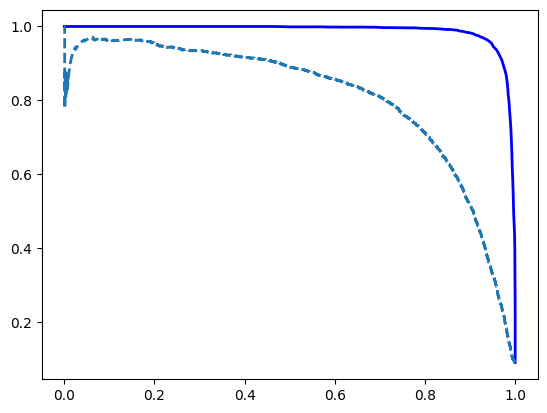

In [26]:
y_scores_forest = y_probas_forest[:,1]
precision_forest  , recall_forest, thresholds_forest = precision_recall_curve(y_train_5, y_scores_forest)
plt.plot(recall_forest,precision_forest, "b-", linewidth=2)

plt.plot(recalls, precisions, "--", linewidth=2, label = "SDG")
[...]
plt.show()

In [27]:
y_train_pred_forest = y_probas_forest[:,1] >= 0.5
f1_score(y_train_5,y_train_pred_forest)
roc_auc_score(y_train_5, y_scores_forest)

0.9983436731328145

In [28]:
from sklearn.svm import SVC
svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])
svm_clf.predict([some_digit])




array(['9'], dtype=object)

In [29]:
some_digit_scores= svm_clf.decision_function([some_digit])
some_digit_scores.round(2)




array([[0.72, 0.72, 2.74, 6.11, 8.27, 3.9 , 0.71, 7.28, 5.08, 9.31]])

In [30]:
class_id = some_digit_scores.argmax()
print(class_id)
    

9


In [31]:
svm_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [33]:
svm_clf.classes_[class_id]

'9'

In [40]:
from sklearn.multiclass import OneVsRestClassifier
ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

ovr_clf.predict([some_digit])


array(['9'], dtype='<U1')

In [41]:
len(ovr_clf.estimators_)

10

In [43]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train[:2000], y_train[:2000])
sgd_clf.predict([some_digit])

/home/at1/Desktop/ML/practicas_ml/02_end_to_end/venv/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array(['9'], dtype='<U1')

In [44]:
sgd_clf.decision_function([some_digit]).round(2)

array([[  -51190.59,   -42060.47,   -88677.78, -1284950.51,   -44660.14,
         -868750.07,   -69727.69,   -26031.19,  -822392.62,   302961.4 ]])

In [45]:
cross_val_score(sgd_clf,X_train[:2000],y_train[:2000],cv=3,scoring = "accuracy")

/home/at1/Desktop/ML/practicas_ml/02_end_to_end/venv/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/at1/Desktop/ML/practicas_ml/02_end_to_end/venv/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/at1/Desktop/ML/practicas_ml/02_end_to_end/venv/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([0.8065967 , 0.77361319, 0.84234234])

In [51]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))
cross_val_score(sgd_clf,X_train_scaled[:2000],y_train[:2000],cv=3,scoring = "accuracy")

array([0.84707646, 0.8155922 , 0.85435435])

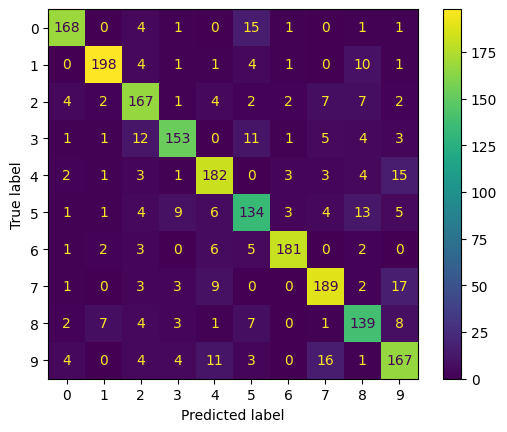

In [55]:
#analisis de errores
from sklearn.metrics import ConfusionMatrixDisplay

y_train_pred = cross_val_predict(sgd_clf,X_train_scaled[:2000],y_train[:2000],cv=3)
ConfusionMatrixDisplay.from_predictions(y_train[:2000],y_train_pred)
plt.show()

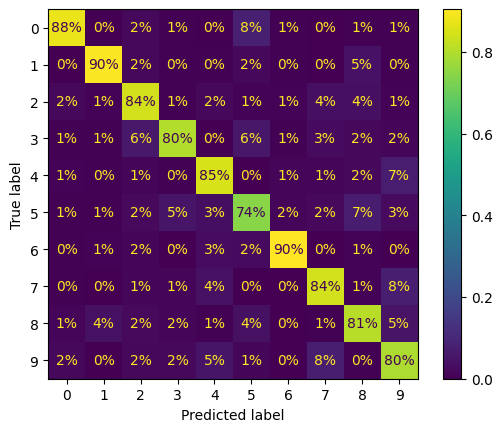

In [59]:
ConfusionMatrixDisplay.from_predictions(y_train[:2000],y_train_pred,normalize='true', values_format=".0%")
plt.show()

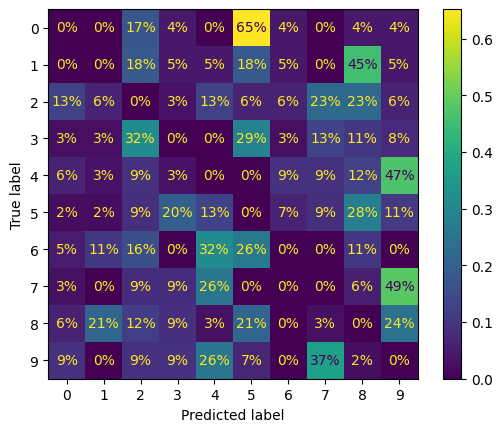

In [77]:
y_train=y_train[:2000]
sample_weight = (y_train_pred != y_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, sample_weight=sample_weight, normalize = 'true', values_format = "0.0%")
plt.show()

In [78]:
cl_a, cl_b =  '3', '5'


X_aa = (y_train == cl_a) &  (y_train_pred == cl_a)
X_ab = (y_train == cl_a) &  (y_train_pred == cl_b)
X_ba = (y_train == cl_b) &  (y_train_pred == cl_a)
X_bb = (y_train == cl_b) &  (y_train_pred == cl_b)

[...]

[Ellipsis]

In [ ]:
y_train=mnist.target[:6000]


array(['5', '0', '4', ..., '8', '6', '9'], shape=(6000,), dtype=object)

In [94]:
#Clasificaicón multietiqueta

import numpy as np
from sklearn.neighbors import KNeighborsClassifier
y_train_large = (y_train >= "7")
y_train_odd = (y_train.astype('int8') % 2 ==1)
y_multilabel = np.c_[y_train_large,y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel[:60000])


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [95]:
knn_clf.predict([some_digit])


array([[ True,  True]])

In [106]:

from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

y_multilabel=y_multilabel[:60000]
y_train_knn_pred = cross_val_predict(knn_clf,X_train,y_multilabel,cv=3)
f1_score(y_multilabel,y_train_knn_pred,average='macro')


0.9764102655606048

In [97]:
from sklearn.multioutput import ClassifierChain

chain_clf = ClassifierChain(SVC(), cv= 3, random_state=42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000])

chain_clf.predict([some_digit])


array([[1., 1.]])

In [98]:
#clasificación multisalida

np.random.seed(42)
noise = np.random.randint(0,100 ,(len(X_train),784 ))
X_train_mod = X_train +noise
noise =np.random.randint(0,100 ,(len(X_test),784 ))
X_test_mod = X_test +noise


y_train_mod = X_train
y_test_mode  = X_test



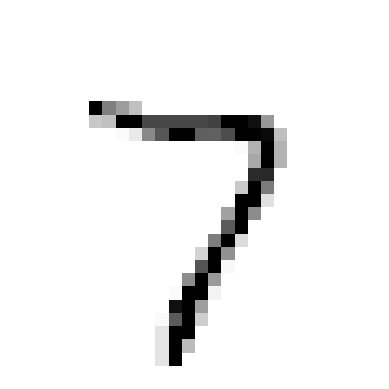

In [109]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod,y_train_mod)
clean_digit=knn_clf.predict([X_test_mod[0]])
plot_digit(knn_clf.predict([X_test_mod[0]]))
plot_digit(clean_digit)
plt.show()